### Implemtation TIBs Bars 

Tick imbalance bars 

$$
T*= \arg \min_{T} ( \theta_T \ge (E_0[T](2P(b_t=1)-1)) 
$$

- T* last index fisnish bar
- $\arg\min$ condition
- $\theta_T$ fact imbalance
- $E_0[T]$ expected size var 
- $(2P(b_t=1)-1)$ media movil de las bars anteriores para bt

$$
E_0[T]=(1-\lambda)T_{i-1} + \lambda E_0[T]_{i-1}
$$

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Imports completados")

✓ Imports completados


In [2]:
from pathlib import Path
import sys

cwd = Path().resolve()
for p in [cwd] + list(cwd.parents):
    if (p / "utils").is_dir():
        sys.path.insert(0, str(p))
        break

from utils.download_data_binance import DowloadDataBinance


In [3]:
data_path = '../data/raw'
dowload_data = DowloadDataBinance(data_path)

df = dowload_data.download_trades_binance(
    symbol='BTCUSDT',
    hours=120,  
    max_trades=300000
)

dowload_data.show_info(df)

Descargando trades de BTCUSDT...
Trades: 200,000 | Iter: 200
✓ Descargados: 200,000 trades
Guardado en: ../data/rawBTCUSDT_trades_20251024_221214.csv

INFORMACIÓN DE LOS DATOS
Total trades: 72,637
Período: 2025-10-20 03:10:32.233000 a 2025-10-20 06:26:31.115000
Duración: 3.3 horas

Primeros 5 trades:
                timestamp      price  quantity  dollar_value
0 2025-10-20 03:10:32.233  108595.80   0.00460    499.540680
1 2025-10-20 03:10:32.565  108595.79   0.00019     20.633200
2 2025-10-20 03:10:32.790  108595.80   0.00008      8.687664
3 2025-10-20 03:10:33.037  108595.79   0.00918    996.909352
4 2025-10-20 03:10:33.282  108595.80   0.00047     51.040026

Estadísticas:
                           timestamp          price      quantity  \
count                          72637   72637.000000  72637.000000   
mean   2025-10-20 04:48:39.877698304  110294.694733      0.022537   
min       2025-10-20 03:10:32.233000  108595.790000      0.000010   
25%    2025-10-20 03:55:13.188999936  110

In [483]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108727 entries, 0 to 108726
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   timestamp     108727 non-null  datetime64[ns]
 1   price         108727 non-null  float64       
 2   quantity      108727 non-null  float64       
 3   dollar_value  108727 non-null  float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 3.3 MB


In [484]:
df.head(5)

,timestamp,price,quantity,dollar_value
0,2025-10-18 15:53:14.057,106935.98,0.01208,1291.786638
1,2025-10-18 15:53:14.516,106935.97,0.00590,630.922223
2,2025-10-18 15:53:14.522,106935.98,0.00045,48.121191
3,2025-10-18 15:53:14.775,106935.98,0.00020,21.387196
4,2025-10-18 15:53:15.537,106935.97,0.02629,2811.346651


In [ ]:
# get ticket directions 

def update_prob_buy(bar_b_t, current_prob, lambda_):
    recent_prob = (bar_b_t == 1).mean()
    # Suavizado exponencial doble para mayor estabilidad
    return (1 - lambda_**2) * recent_prob + lambda_**2 * current_prob


def get_tick_directions(df: pd.DataFrame) -> pd.Series:
    price_diff = df['price'].diff() # firence previus and acutal price
    b_t = np.sign(price_diff) # get a sign 
    
    b_t = b_t.replace(0, np.nan).ffill().fillna(1) # 0 -> Nan, fill series valid value, first (1)
    return b_t

def tick_imbalance_bars(
    df: pd.DataFrame, exp_lambda = 0.9, init_exp_T = 1600, init_p_buy=0.5) -> pd.DataFrame:
    df = df.copy()
    df['b_t'] = get_tick_directions(df)
    
    # initial 
    E_T = init_exp_T
    prob_buy = init_p_buy
    bars = []
    tick_imbalance = 0
    tick_count = 0 
    last_index = 0 
    
    for i in range(1, len(df)):
        tick_count += 1
        tick_imbalance += df.loc[i, 'b_t'] 
        
        # stop condition 
        thereshold = E_T * abs(2 * prob_buy - 1) 
        # Añade un mínimo de ticks para evitar barras muy cortas
        MIN_TICKS = 20
        if abs(tick_imbalance) >= thereshold and tick_count >= MIN_TICKS:
            # Formar barra
            bar = df.iloc[last_index:i+1]
            bars.append({
                'open_time': bar['timestamp'].iloc[0],
                'close_time': bar['timestamp'].iloc[-1],
                'open': bar['price'].iloc[0],
                'high': bar['price'].max(),
                'low': bar['price'].min(),
                'close': bar['price'].iloc[-1],
                'n_ticks': len(bar),
                'volume': bar['quantity'].sum(),
                'dollar_value': bar['dollar_value'].sum(),
            })
            
            # update waited 
            E_T =(1 - exp_lambda) * len(bar) + exp_lambda * E_T 
            prob_buy = update_prob_buy(bar['b_t'], prob_buy, exp_lambda)

            
            # Reset
            tick_imbalance = 0 
            tick_count = 0 
            last_index = i + 1
    
    bars_df = pd.DataFrame(bars)    
    return bars_df

In [486]:
tib_bars = tick_imbalance_bars(df)
print(tib_bars.head(5).sort_index())


                open_time              close_time       open       high  \
0 2025-10-18 15:53:14.057 2025-10-18 15:53:21.586  106935.98  106935.98   
1 2025-10-18 15:53:21.632 2025-10-18 15:53:44.086  106935.97  106938.00   
2 2025-10-18 15:53:44.088 2025-10-18 15:55:46.232  106937.15  106973.39   
3 2025-10-18 15:55:46.458 2025-10-18 16:01:27.517  106973.39  106978.85   
4 2025-10-18 16:01:27.788 2025-10-18 16:02:50.265  106973.54  106992.00   

         low      close  n_ticks   volume   dollar_value  
0  106935.97  106935.98       21  0.07762    8300.370302  
1  106930.73  106938.00       62  0.48237   51581.033936  
2  106937.15  106973.39      262  1.21226  129671.047922  
3  106935.04  106970.31      869  7.70863  824471.423307  
4  106970.51  106990.20      331  3.46267  370451.410402  


In [487]:
print('num bars:',len(tib_bars))

num bars: 50


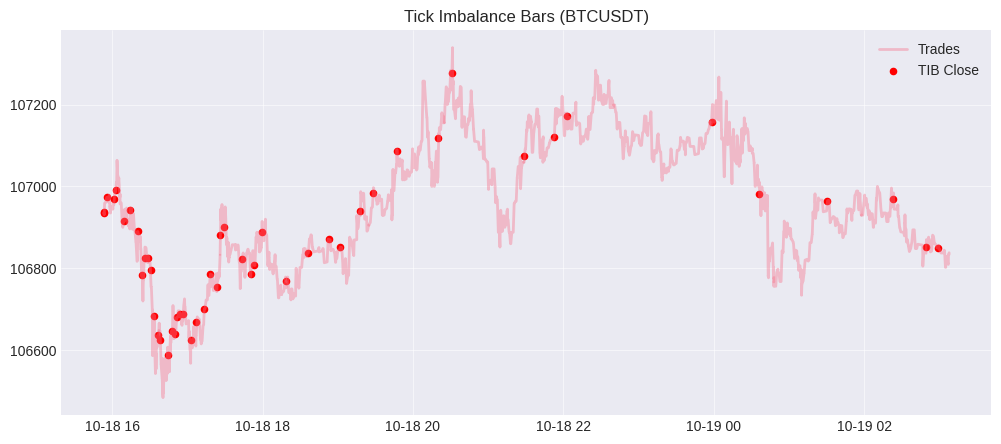

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df['timestamp'], df['price'], alpha=0.4, label='Trades')
plt.scatter(tib_bars['close_time'], tib_bars['close'], color='red', s=20, label='TIB Close')
plt.legend()
plt.title('Tick Imbalance Bars (BTCUSDT)')
plt.show()


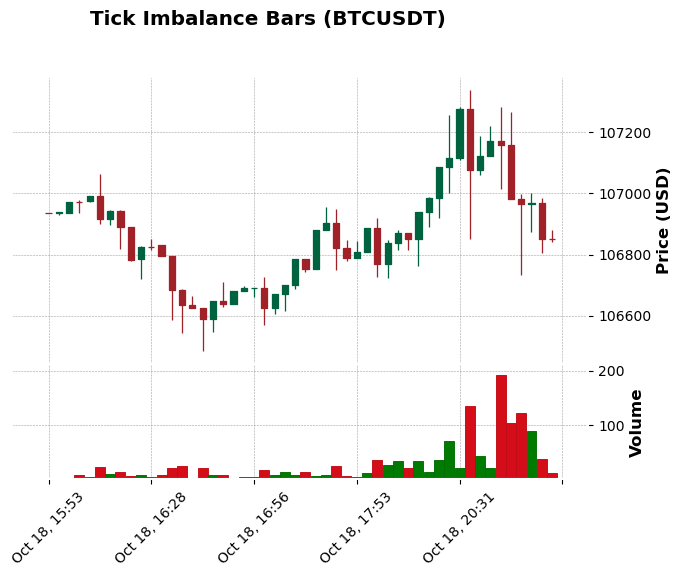

In [489]:
import mplfinance as mpf

tib_bars.set_index('close_time', inplace=True)

mpf.plot(
    tib_bars,
    type='candle',
    style='charles',
    volume=True,
    title='Tick Imbalance Bars (BTCUSDT)',
    ylabel='Price (USD)',
    ylabel_lower='Volume',
)
